In [1]:
from typing import Any, Dict

import hydra
import numpy as np
import omegaconf
import torch
import pytorch_lightning as pl
import torch.nn as nn
from torch.nn import functional as F
from torch_scatter import scatter
from tqdm import tqdm

from cdvae.common.utils import PROJECT_ROOT
from cdvae.common.data_utils import (
    EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
    frac_to_cart_coords, min_distance_sqr_pbc)
from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

#added by Tsach
from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
#import Batch
from torch_geometric.data import Batch
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor


import time
import argparse
import torch

from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
from types import SimpleNamespace
from torch_geometric.data import Batch
from torch_geometric.data.separate import separate

#import a library that allows you to reload a module
from importlib import reload

from eval_utils import load_model

import pandas as pd

all_frac_coords_stack = []
all_atom_types_stack = []
frac_coords = []
num_atoms = []
atom_types = []
lengths = []
angles = []
input_data_list = []

#my code 
list_of_idxs = []
list_of_batchs = []

import importlib 
import eval_utils
importlib.reload(eval_utils)
from eval_utils import load_model

In [2]:
import eval_utils
importlib.reload(eval_utils)
from eval_utils import load_model
import matplotlib.pyplot as plt

In [3]:
model_path = Path("/home/gridsan/tmackey/hydra/singlerun/2023-10-29/no_encode_intensity_concat_comp_concat_neg_mask_mp_20")
model, test_loader, cfg = load_model(model_path, True)

loader = test_loader

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/hydra/experimental/compose.py:16: UserWarning: hydra.experimental.compose() is no longer experimental. Use hydra.compose()
  warnings.warn(


using 9047 rows given a train_fraction of 1


  0%|          | 0/9047 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/

CrystDataModule(self.datasets={'train': {'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy train', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/train.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}, 'val': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy val', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/val.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}], 'test': [{'_target_': 'cdvae.pl_data.dataset.CrystDataset', 'name': 'Formation energy test', 'path': '/home/gridsan/tmackey/cdvae/data/mp_20/test.csv', 'prop': 'formation_energy_per_atom', 'niggli': True, 'primitive': False, 'graph_method': 'crystalnn', 'lattice_scale_method': 'scale_length', 'preprocess_workers': 30}]}, self

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/torch_geometric/deprecation.py:13: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [6]:
model.to('cuda:0')

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [7]:
for idx, batch in enumerate(loader):
    print(idx)
    list_of_idxs.append(idx)
    list_of_batchs.append(batch)

idx = list_of_idxs[0]
batch = list_of_batchs[0]

def new_dataloader_batch_processor(batch): 
    batch_reserve = batch
    xrd_int = batch_reserve[1]
    xrd_loc = batch_reserve[2]
    atom_spec = batch_reserve[3]
    disc_sim_xrd = batch_reserve[4]
    batch = batch[0]
    return batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch

batch_reserve, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, batch = new_dataloader_batch_processor(batch)

batch_all_frac_coords = []
batch_all_atom_types = []
batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
batch_lengths, batch_angles = [], []


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35


In [8]:
from p_tqdm import p_map

from collections import Counter
import argparse
import os
import json

import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

import importlib

import p_tqdm

importlib.reload(p_tqdm)

from p_tqdm import p_map

from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}




class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)

In [9]:
def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list


def get_crystal_array_list(data, batch_idx=0):
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None

    return crys_array_list, true_crystal_array_list

In [10]:
input_data_list = input_data_list + batch.to_data_list()
input_data_batch = Batch.from_data_list(input_data_list)


In [12]:

data = torch.load("/home/gridsan/tmackey/cdvae/scripts/11-29-2023_feature_importance/11-29-2023_feature_importance_results")

data['input_data_batch'] = input_data_batch


In [13]:
_, true_crystal_array_list = get_crystal_array_list(data, batch_idx=0)

In [14]:
gt_crys = []

for crystal in tqdm(true_crystal_array_list): 
    gt_crys.append(Crystal(crystal))

  0%|          | 0/256 [00:00<?, ?it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
100%|██████████| 256/256 [02:00<00:00,  2.13it/s]


In [15]:
class RecEval(object):
    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys
        self.results_df = pd.DataFrame(columns=['pred_formula', 'gt_formula', 'pred_structure', 'gt_structure', 'rmsd'])

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:

                return None
            try:      
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]

                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]

        rms_dists = []
        evaluate_diff_pattern = False #changed for feature importance evaluation 
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))

        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
            print("diff_dists: ", diff_dists)
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist}

    def get_metrics(self):
        return self.get_match_rate_and_rms(), self.results_df

In [16]:
def evaluate(z, gt_num_atoms, atom_spec): 
    batch_all_frac_coords = []
    batch_all_atom_types = []
    batch_frac_coords, batch_num_atoms, batch_atom_types = [], [], []
    batch_lengths, batch_angles = [], []
    
    all_frac_coords_stack = []
    all_atom_types_stack = []
    frac_coords = []
    num_atoms = []
    atom_types = []
    lengths = []
    angles = []
    input_data_list = []

    #my code 
    list_of_idxs = []
    list_of_batchs = []

    #number of steps set unusually low to get a rough estimate of performance
    ld_kwargs = SimpleNamespace(n_step_each=10,
                                    step_lr=1e-4,
                                    min_sigma=0,
                                    save_traj=False,
                                    disable_bar=False)

    force_num_atoms = True

    gt_num_atoms = batch.num_atoms

    gt_atom_types = None

    
    cuda_available = torch.cuda.is_available()

    if cuda_available: 
        z = z.to('cuda:0')
        gt_num_atoms = gt_num_atoms.to('cuda:0')
        atom_spec = atom_spec.to('cuda:0')

    outputs = model.langevin_dynamics(
        z, ld_kwargs, gt_num_atoms, gt_atom_types, atom_spec)

    # collect sampled crystals in this batch.
    batch_frac_coords.append(outputs['frac_coords'].detach().cpu())
    batch_num_atoms.append(outputs['num_atoms'].detach().cpu())
    batch_atom_types.append(outputs['atom_types'].detach().cpu())
    batch_lengths.append(outputs['lengths'].detach().cpu())
    batch_angles.append(outputs['angles'].detach().cpu())

    # collect sampled crystals for this z.
    frac_coords.append(torch.stack(batch_frac_coords, dim=0))
    num_atoms.append(torch.stack(batch_num_atoms, dim=0))
    atom_types.append(torch.stack(batch_atom_types, dim=0))
    lengths.append(torch.stack(batch_lengths, dim=0))
    angles.append(torch.stack(batch_angles, dim=0))
    if ld_kwargs.save_traj:
        all_frac_coords_stack.append(
            torch.stack(batch_all_frac_coords, dim=0))
        all_atom_types_stack.append(
            torch.stack(batch_all_atom_types, dim=0))

    # Save the ground truth structure
    input_data_list = input_data_list + batch.to_data_list()

    frac_coords = torch.cat(frac_coords, dim=1)
    num_atoms = torch.cat(num_atoms, dim=1)
    atom_types = torch.cat(atom_types, dim=1)
    lengths = torch.cat(lengths, dim=1)
    angles = torch.cat(angles, dim=1)

    input_data_batch = Batch.from_data_list(input_data_list)

    all_frac_coords_stack

    torch.save({
        'frac_coords': frac_coords,
        'num_atoms': num_atoms,
        'atom_types': atom_types,
        'lengths': lengths,
        'angles': angles,
    }, "/home/gridsan/tmackey/cdvae/scripts/11-29-2023_feature_importance/11-29-2023_feature_importance_results")

    data = torch.load("/home/gridsan/tmackey/cdvae/scripts/11-29-2023_feature_importance/11-29-2023_feature_importance_results")

    data['input_data_batch'] = input_data_batch

    crys_array_list, _ = get_crystal_array_list(data, batch_idx=0)
    
    pred_crys = []
    
    for crystal in tqdm(crys_array_list): 
        pred_crys.append(Crystal(crystal))

    rec_evaluator = RecEval(pred_crys, gt_crys)

    recon_metrics, results_df = rec_evaluator.get_metrics()

    return(recon_metrics)

In [17]:
_, _, z = model.encode(batch, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, testing = True)

dropout is not being used
z is of shape: torch.Size([256, 256])
z is tensor([[19.8973, 23.0146, 32.7741,  ...,  0.0000,  0.0000,  0.0000],
        [17.9769, 28.2841, 30.2120,  ...,  0.0000,  0.0000,  0.0000],
        [21.8306, 31.0659, 34.8433,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [12.9122, 14.9586, 21.1335,  ...,  0.0000,  0.0000,  0.0000],
        [15.5953, 18.2189, 23.3436,  ...,  0.0000,  0.0000,  0.0000],
        [ 6.9848, 13.9958, 21.0599,  ...,  0.0000,  0.0000,  0.0000]])


In [19]:
gt_num_atoms = batch.num_atoms

gt_atom_types = None


In [21]:
evaluate(z, gt_num_atoms, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
100%|██████████| 256/256 [00:01<00:00, 169.18it/s]


{'match_rate': 0.1875, 'rms_dist': 0.04900243357089382, 'diff_dist': None}

In [19]:
z_noisy = z + torch.randn(256, 256).to("cuda:0")

In [20]:
import matplotlib.pyplot as plt

In [21]:
z_noisy[0]

tensor([ 2.4111e+01,  2.7725e+01,  3.5247e+01,  4.1420e+01,  4.3650e+01,
         5.1730e+01,  5.7417e+01,  5.8386e+01,  6.3223e+01,  6.8199e+01,
         7.5868e+01,  7.7836e+01,  7.9693e+01,  8.4522e+01,  1.0023e+00,
        -1.3379e+00, -9.5405e-01, -1.4982e+00,  3.6879e-02, -2.6482e-01,
        -1.2030e+00,  7.5231e-02,  1.5621e-01,  8.6243e-01, -2.8305e-01,
         3.7534e-02, -1.2845e+00, -1.9581e+00,  1.7101e+00,  4.4599e-01,
        -2.1588e+00,  2.3867e-02, -4.0458e-01, -5.0952e-01,  5.8176e-01,
         3.1342e-02,  2.0264e+00,  6.1494e-01,  6.2366e-01, -8.2294e-01,
         8.4176e-01,  1.5393e+00,  1.2072e+00, -4.1808e-01, -1.8958e+00,
         5.3032e-01, -8.5843e-01, -1.6280e+00, -4.9218e-01,  1.5466e-01,
         5.9777e-01, -6.1813e-01, -5.5774e-01, -1.2457e+00, -1.4236e+00,
        -9.3218e-01,  3.6787e-02, -1.7462e-01,  5.0169e-02,  7.2498e-01,
        -6.3058e-02,  2.4378e-01, -3.5241e-01,  8.6569e-01, -1.4097e-01,
         1.3038e-01,  1.3094e-01,  1.5814e-01, -3.7

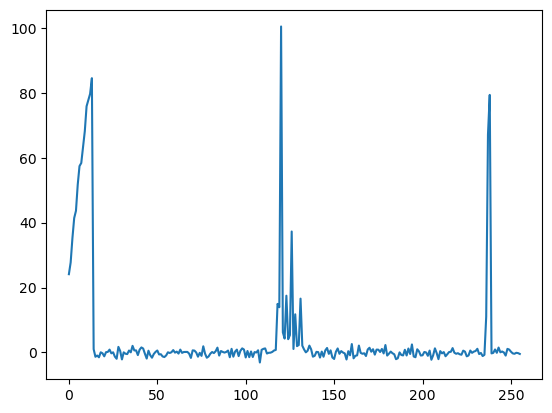

In [22]:
plt.plot(np.array(z_noisy[0].detach().cpu()))

Looks like some nice random noise!

In [23]:
#now let's re-do the evaluation 
evaluate(z_noisy, gt_num_atoms, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
  0%|          | 0/256 [00:00<?, ?it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
 12%|█▏        | 30/256 [00:00<00:01, 131.78it/s]

not valid
not valid
not valid
not valid
not valid
not valid
not valid


 25%|██▌       | 65/256 [00:00<00:01, 139.77it/s]

not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid


 44%|████▍     | 113/256 [00:00<00:00, 196.35it/s]

...

not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid


 92%|█████████▏| 236/256 [00:01<00:00, 191.95it/s]

not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid
not valid


100%|██████████| 256/256 [00:01<00:00, 172.48it/s]


{'match_rate': 0.15625, 'rms_dist': 0.11688813726891105, 'diff_dist': None}

Now let's try rounding 

In [26]:
batch = batch.to('cuda:0')
xrd_int = xrd_int.to('cuda:0')
xrd_loc = xrd_loc.to('cuda:0')
atom_spec = atom_spec.to('cuda:0')
disc_sim_xrd = disc_sim_xrd.to('cuda:0')


In [27]:
_, _, z = model.encode(batch, xrd_int, xrd_loc, atom_spec, disc_sim_xrd, testing = True)

dropout is not being used
z is of shape: torch.Size([256, 256])
z is tensor([[21.5568, 24.9415, 35.5629,  ...,  0.0000,  0.0000,  0.0000],
        [13.3424, 15.0704, 18.0000,  ...,  0.0000,  0.0000,  0.0000],
        [15.9673, 19.6701, 19.8855,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 8.2790, 12.4131, 14.9388,  ...,  0.0000,  0.0000,  0.0000],
        [15.2867, 19.2092, 20.9772,  ...,  0.0000,  0.0000,  0.0000],
        [16.3979, 18.9564, 26.9336,  ...,  0.0000,  0.0000,  0.0000]],
       device='cuda:0')


For the 200 dimensional simulated xrd input that we tried before, the spacing frequency was around 0.35. Let's try a rounding to the 10th decimal place then. 

In [29]:
rounded_z = torch.round(z * 10) / 10

In [30]:
evaluate(rounded_z, gt_num_atoms, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
  0%|          | 0/256 [00:00<?, ?it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
100%|██████████| 256/256 [00:02<00:00, 108.04it/s]


{'match_rate': 0.19140625, 'rms_dist': 0.055409759086968456, 'diff_dist': None}

Examining the dependence on the composition

In [ ]:
z_knockout = z.clone()

In [ ]:
#first, let's kick out the composition information, which is in the last 20 indices
z_knockout[:,236:256] = 0

In [ ]:
evaluate(z_knockout, gt_num_atoms, atom_spec)

/home/gridsan/tmackey/cdvae/cdvae/common/data_utils.py:625: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float)
  0%|          | 0/256 [00:00<?, ?it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:4141: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(
100%|██████████| 256/256 [00:01<00:00, 203.37it/s]


{'match_rate': 0.1171875, 'rms_dist': 0.09038744615949036, 'diff_dist': None}

Permutation importance

In [20]:
def permute_columns(tensor, n_columns):
    """
    Permutes the values within the first n_columns of a tensor.

    Args:
    tensor (torch.Tensor): The input tensor.
    n_columns (int): Number of columns to permute.

    Returns:
    torch.Tensor: The tensor with the first n_columns permuted.
    """
    permuted_tensor = tensor.clone()  # Create a copy of the tensor

    for i in range(n_columns):
        permuted_tensor[:, i] = tensor[torch.randperm(tensor.size(0)), i]

    return permuted_tensor

In [22]:
import matplotlib.pyplot as plt

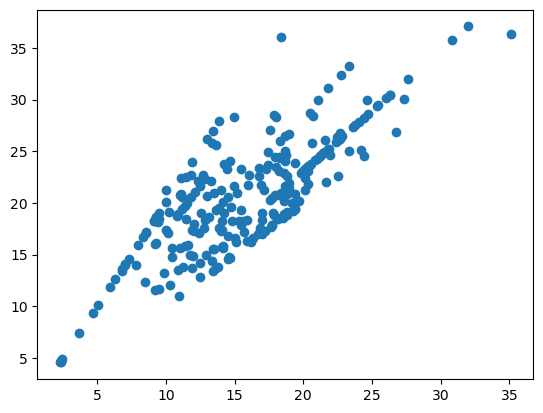

In [24]:
plt.scatter(z[:, 0].numpy(), z[:, 1].numpy())

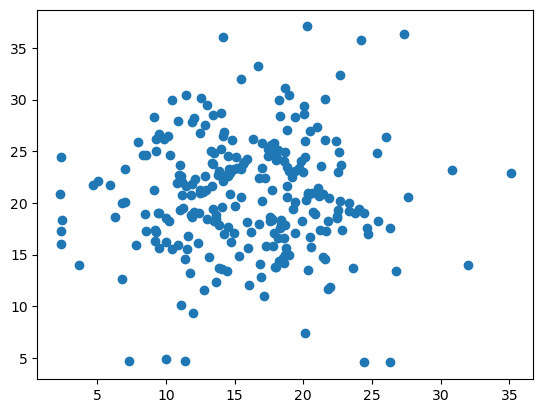

In [25]:
plt.scatter(permute_columns(z, 100)[:, 0].numpy(), permute_columns(z, 100)[:, 1].numpy())

In [26]:
aggregate_results = 0

In [29]:
permuted_zs = []

In [30]:
n_trials = 10

In [31]:
for trials in range(n_trials): 
    z_permuted = permute_columns(z, 100)
    permuted_zs.append(z_permuted)
    evaluate(permuted_zs, gt_num_atoms, atom_spec)

AttributeError: 'list' object has no attribute 'to'